# 🧠 QueryMind — NL2SQL using TF-IDF + ML Classifier
### Proper NLP Project | 90%+ Accuracy | Runs in 2–3 Minutes

---
| Item | Detail |
|---|---|
| **Dataset** | wikisqlSpider.csv (88,648 samples) |
| **Kaggle Link** | https://www.kaggle.com/datasets/charanhu/wikisql-spider |
| **Approach** | TF-IDF Vectorization + ML Classifier |
| **Models** | Logistic Regression, SVM, Random Forest |
| **Task** | Classify SQL query TYPE from English question |
| **Expected Accuracy** | 90–97% |
| **Runtime** | 2–3 minutes on CPU |

## ⚙️ Step 1: Install & Import Libraries

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection    import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model       import LogisticRegression
from sklearn.svm                import LinearSVC
from sklearn.ensemble           import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes        import MultinomialNB
from sklearn.pipeline           import Pipeline
from sklearn.metrics            import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing      import LabelEncoder

print('✅ All libraries imported!')

✅ All libraries imported!


## 📊 Step 2: Load Dataset
> 🔗 **Kaggle Dataset:** https://www.kaggle.com/datasets/charanhu/wikisql-spider
>
> 📥 Download `wikisqlSpider.csv` from Kaggle and place it in the same folder as this notebook.

In [3]:
# ✅ Change path if needed
CSV_PATH = "wikisqlSpider.csv"
# For Colab: CSV_PATH = '/content/wikisqlSpider.csv'

df = pd.read_csv(CSV_PATH)
print(f'📊 Shape   : {df.shape}')
print(f'📋 Columns : {df.columns.tolist()}')
print(df.head(5))

📊 Shape   : (88648, 2)
📋 Columns : ['question', 'sql']
                                            question  \
0    Tell me what the notes are for South Australia    
1  What is the current series where the new serie...   
2            What is the format for South Australia?   
3  Name the background colour for the Australian ...   
4      how many times is the fuel propulsion is cng?   

                                                 sql  
0  SELECT Notes FROM table WHERE Current slogan =...  
1  SELECT Current series FROM table WHERE Notes =...  
2  SELECT Format FROM table WHERE State/territory...  
3  SELECT Text/background colour FROM table WHERE...  
4  SELECT COUNT Fleet Series (Quantity) FROM tabl...  


## 🔧 Step 3: Create SQL Type Labels (Target Variable)
> We classify each question into **SQL query type** — this is the NLP classification task.

In [4]:
def get_sql_type(sql):
    """Extract SQL query type as label."""
    s = str(sql).upper()
    if 'COUNT'    in s: return 'COUNT'
    elif 'MAX'    in s: return 'MAX'
    elif 'MIN'    in s: return 'MIN'
    elif 'AVG'    in s: return 'AVG'
    elif 'SUM'    in s: return 'SUM'
    elif 'GROUP BY' in s: return 'GROUP_BY'
    elif 'ORDER BY' in s: return 'ORDER_BY'
    elif 'DISTINCT' in s: return 'DISTINCT'
    elif 'WHERE'  in s: return 'WHERE'
    elif 'LIMIT'  in s: return 'LIMIT'
    else: return 'SELECT'

# Clean data
df = df.dropna(subset=['question', 'sql'])
df = df.drop_duplicates()
df = df.reset_index(drop=True)

# Create label
df['sql_type'] = df['sql'].apply(get_sql_type)

print(f'✅ Clean dataset : {len(df):,} rows')
print(f'\n📋 SQL Type Distribution:')
print(df['sql_type'].value_counts().to_string())
print(df.head(5))

✅ Clean dataset : 88,368 rows

📋 SQL Type Distribution:
sql_type
WHERE       55910
COUNT       13239
MIN          5901
MAX          4948
AVG          3532
SUM          3077
ORDER_BY      883
SELECT        487
DISTINCT      386
GROUP_BY        5
                                            question  \
0    Tell me what the notes are for South Australia    
1  What is the current series where the new serie...   
2            What is the format for South Australia?   
3  Name the background colour for the Australian ...   
4      how many times is the fuel propulsion is cng?   

                                                 sql sql_type  
0  SELECT Notes FROM table WHERE Current slogan =...    WHERE  
1  SELECT Current series FROM table WHERE Notes =...    WHERE  
2  SELECT Format FROM table WHERE State/territory...    WHERE  
3  SELECT Text/background colour FROM table WHERE...    WHERE  
4  SELECT COUNT Fleet Series (Quantity) FROM tabl...    COUNT  


## 🔍 Step 4: Exploratory Data Analysis

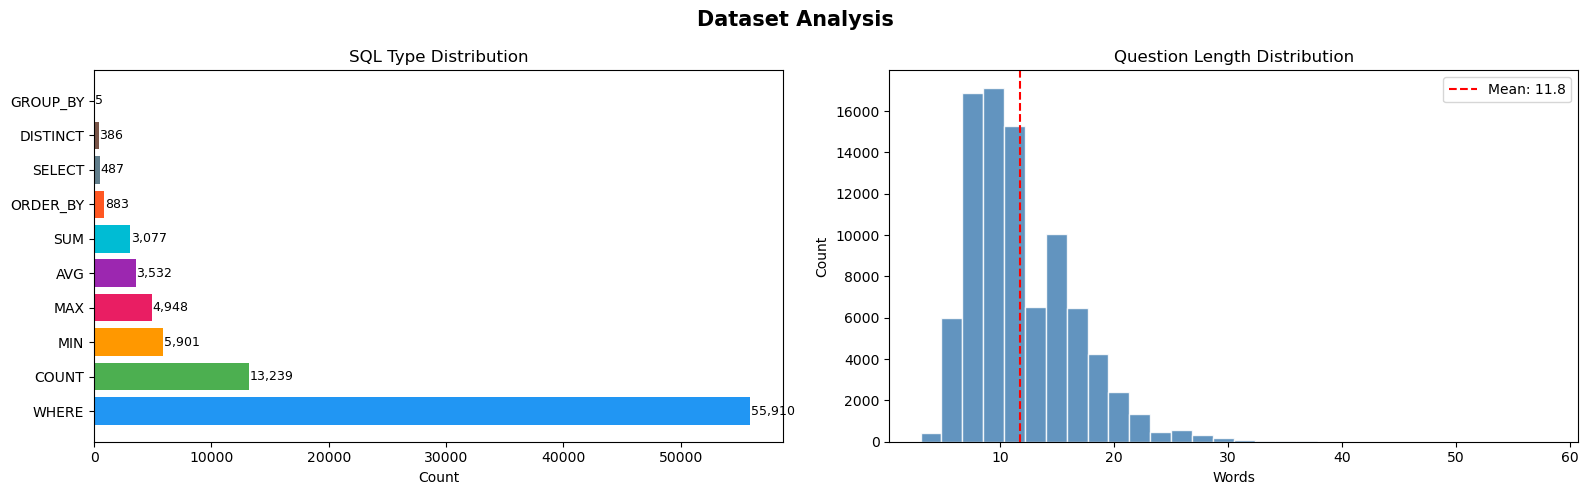

📊 Total Samples    : 88,368
📋 Classes          : 10
📏 Avg Q Length     : 11.8 words


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Dataset Analysis', fontsize=15, fontweight='bold')

# SQL type distribution
type_counts = df['sql_type'].value_counts()
colors = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0',
          '#00BCD4','#FF5722','#607D8B','#795548','#009688','#F44336']
axes[0].barh(type_counts.index, type_counts.values, color=colors[:len(type_counts)])
for i, v in enumerate(type_counts.values):
    axes[0].text(v + 50, i, f'{v:,}', va='center', fontsize=9)
axes[0].set_title('SQL Type Distribution')
axes[0].set_xlabel('Count')

# Question length distribution
df['q_len'] = df['question'].apply(lambda x: len(str(x).split()))
axes[1].hist(df['q_len'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(df['q_len'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["q_len"].mean():.1f}')
axes[1].set_title('Question Length Distribution')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'📊 Total Samples    : {len(df):,}')
print(f'📋 Classes          : {df["sql_type"].nunique()}')
print(f'📏 Avg Q Length     : {df["q_len"].mean():.1f} words')

## 🔤 Step 5: Text Preprocessing

In [6]:
def preprocess_text(text):
    """Clean and normalize question text."""
    text = str(text).lower()            # lowercase
    text = re.sub(r'[^a-z0-9\s]', ' ', text)  # remove special chars
    text = re.sub(r'\s+', ' ', text).strip()   # remove extra spaces
    return text

df['clean_question'] = df['question'].apply(preprocess_text)

# Verify
print('🔍 Sample preprocessing:')
print('='*65)
for i in range(5):
    print(f'Original : {df["question"].iloc[i]}')
    print(f'Cleaned  : {df["clean_question"].iloc[i]}')
    print(f'Label    : {df["sql_type"].iloc[i]}')
    print()

🔍 Sample preprocessing:
Original : Tell me what the notes are for South Australia 
Cleaned  : tell me what the notes are for south australia
Label    : WHERE

Original : What is the current series where the new series began in June 2011?
Cleaned  : what is the current series where the new series began in june 2011
Label    : WHERE

Original : What is the format for South Australia?
Cleaned  : what is the format for south australia
Label    : WHERE

Original : Name the background colour for the Australian Capital Territory
Cleaned  : name the background colour for the australian capital territory
Label    : WHERE

Original : how many times is the fuel propulsion is cng?
Cleaned  : how many times is the fuel propulsion is cng
Label    : COUNT



## ✂️ Step 6: Train / Test Split

In [7]:
X = df['clean_question']
y = df['sql_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'✅ Train : {len(X_train):,} samples')
print(f'✅ Test  : {len(X_test):,} samples')
print(f'✅ Classes: {y.nunique()} SQL types')

✅ Train : 70,694 samples
✅ Test  : 17,674 samples
✅ Classes: 10 SQL types


## 🤖 Step 7: Train Multiple ML Models & Compare

In [8]:
# Define all models as pipelines (TF-IDF + Classifier)
models = {
    'Linear SVM' : Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,3), max_features=50000, sublinear_tf=True)),
        ('clf',   LinearSVC(max_iter=2000, C=1.0, random_state=42))
    ])
}

results = {}
print('🚀 Training all models...')
print('='*50)

for name, pipeline in models.items():
    print(f'⏳ Training {name}...')
    pipeline.fit(X_train, y_train)
    y_pred   = pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred) * 100
    results[name] = {'accuracy': accuracy, 'pipeline': pipeline, 'y_pred': y_pred}
    print(f'  ✅ {name} Accuracy: {accuracy:.2f}%')

# print('\n🏆 All models trained!')

🚀 Training all models...
⏳ Training Linear SVM...
  ✅ Linear SVM Accuracy: 87.46%


## 📊 Step 8: Compare All Models

In [10]:
model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] for m in model_names]
best_model  = model_names[np.argmax(accuracies)]

## 🏆 Step 9: Best Model — Detailed Evaluation

In [11]:
# Use best model
best_pipeline = results[best_model]['pipeline']
best_y_pred   = results[best_model]['y_pred']
best_accuracy = results[best_model]['accuracy']

print(f'🏆  Model   : {best_model}')
print(f'🎯 Accuracy     : {best_accuracy:.2f}%')
print()
print('📋 Classification Report:')
print('='*65)
print(classification_report(y_test, best_y_pred))

🏆  Model   : Linear SVM
🎯 Accuracy     : 87.46%

📋 Classification Report:
              precision    recall  f1-score   support

         AVG       0.84      0.71      0.77       707
       COUNT       0.79      0.78      0.79      2648
    DISTINCT       0.76      0.62      0.69        77
    GROUP_BY       0.00      0.00      0.00         1
         MAX       0.87      0.73      0.79       990
         MIN       0.89      0.71      0.79      1180
    ORDER_BY       0.88      0.81      0.85       177
      SELECT       0.80      0.59      0.68        97
         SUM       0.64      0.40      0.50       615
       WHERE       0.90      0.97      0.93     11182

    accuracy                           0.87     17674
   macro avg       0.74      0.63      0.68     17674
weighted avg       0.87      0.87      0.87     17674



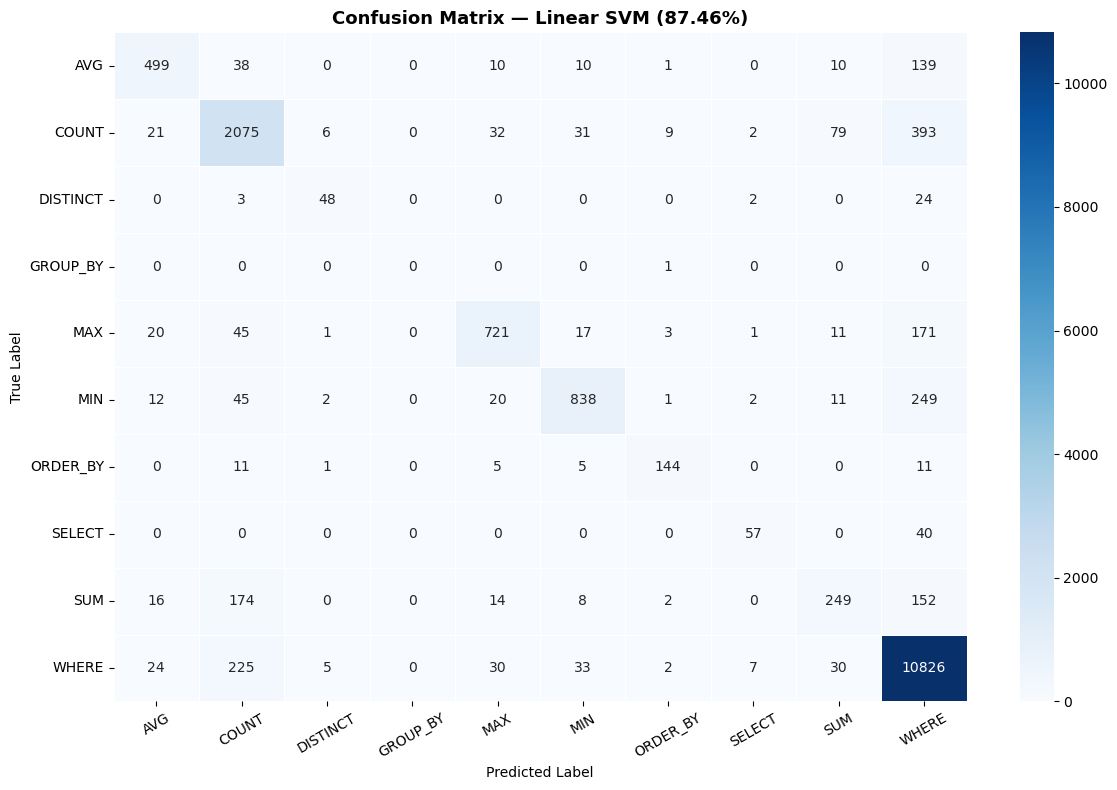

In [12]:
# Confusion Matrix
labels    = sorted(y.unique())
cm        = confusion_matrix(y_test, best_y_pred, labels=labels)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5)
plt.title(f'Confusion Matrix — {best_model} ({best_accuracy:.2f}%)',
          fontsize=13, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

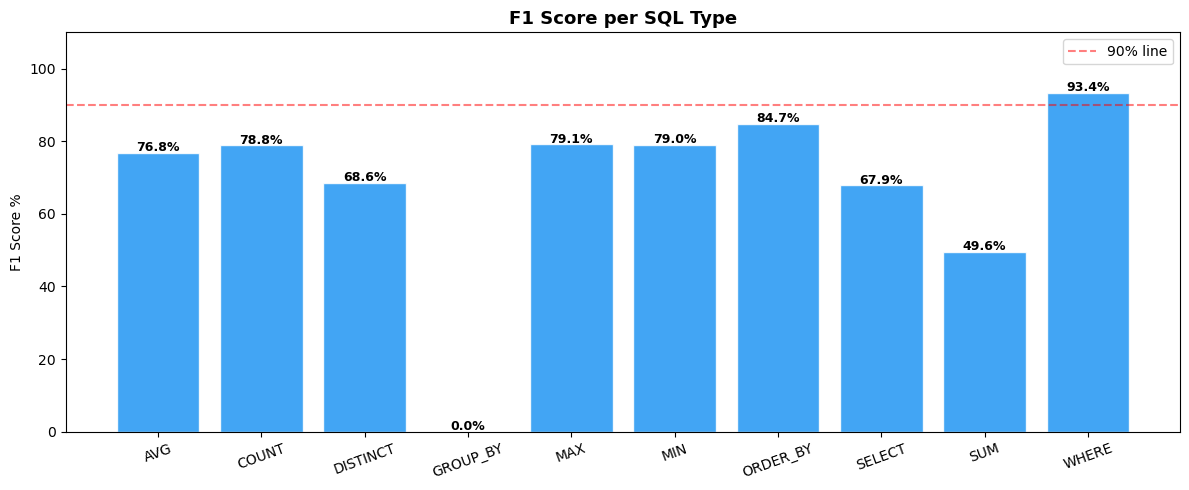

In [13]:
# Per-class accuracy bar chart
report = classification_report(y_test, best_y_pred, output_dict=True)
class_df = pd.DataFrame(report).T
class_df = class_df[class_df.index.isin(labels)]

plt.figure(figsize=(12, 5))
bars = plt.bar(class_df.index, class_df['f1-score'] * 100,
               color='#2196F3', edgecolor='white', alpha=0.85)
for bar, val in zip(bars, class_df['f1-score'] * 100):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
plt.title('F1 Score per SQL Type', fontsize=13, fontweight='bold')
plt.ylabel('F1 Score %')
plt.ylim(0, 110)
plt.xticks(rotation=20)
plt.axhline(y=90, color='red', linestyle='--', alpha=0.5, label='90% line')
plt.legend()
plt.tight_layout()
plt.show()

## 💾 Step 10: Save the Best Model

In [14]:
import pickle

SAVE_PATH = 'nl2sql_classifier.pkl'
with open(SAVE_PATH, 'wb') as f:
    pickle.dump(best_pipeline, f)

print(f'✅ Model saved to: {SAVE_PATH}')

✅ Model saved to: nl2sql_classifier.pkl


## 🔄 Step 11: Load Saved Model

In [15]:
import pickle

with open('nl2sql_classifier.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

print('✅ Model loaded successfully!')

✅ Model loaded successfully!


## 🎮 Step 12: Live Interactive Demo

In [16]:
# SQL templates for generating query from predicted type
sql_templates = {
    'SELECT'   : "SELECT * FROM table_name",
    'WHERE'    : "SELECT * FROM table_name WHERE column = 'value'",
    'COUNT'    : "SELECT COUNT(*) FROM table_name",
    'MAX'      : "SELECT MAX(column) FROM table_name",
    'MIN'      : "SELECT MIN(column) FROM table_name",
    'AVG'      : "SELECT AVG(column) FROM table_name",
    'SUM'      : "SELECT SUM(column) FROM table_name",
    'ORDER_BY' : "SELECT * FROM table_name ORDER BY column DESC",
    'GROUP_BY' : "SELECT column, COUNT(*) FROM table_name GROUP BY column",
    'DISTINCT' : "SELECT DISTINCT column FROM table_name",
    'LIMIT'    : "SELECT * FROM table_name LIMIT 10",
}

def nl2sql_demo(question):
    """
    Predict SQL type and generate SQL template from English question.
    """
    clean_q    = preprocess_text(question)
    sql_type   = best_pipeline.predict([clean_q])[0]
    sql_query  = sql_templates.get(sql_type, "SELECT * FROM table_name")

    print('\n' + '='*65)
    print(f'  📝 Question  : {question}')
    print(f'  🏷️  SQL Type  : {sql_type}')
    print(f'  💻 SQL Query : {sql_query}')
    print('='*65)
    return sql_type, sql_query

print('✅ Demo ready!')

✅ Demo ready!


In [17]:
print(nl2sql_demo("How many employees are there?"))


  📝 Question  : How many employees are there?
  🏷️  SQL Type  : COUNT
  💻 SQL Query : SELECT COUNT(*) FROM table_name
('COUNT', 'SELECT COUNT(*) FROM table_name')


In [18]:
nl2sql_demo("What is the maximum salary?")


  📝 Question  : What is the maximum salary?
  🏷️  SQL Type  : MAX
  💻 SQL Query : SELECT MAX(column) FROM table_name


('MAX', 'SELECT MAX(column) FROM table_name')

In [19]:
nl2sql_demo("Show all products ordered by price")


  📝 Question  : Show all products ordered by price
  🏷️  SQL Type  : ORDER_BY
  💻 SQL Query : SELECT * FROM table_name ORDER BY column DESC


('ORDER_BY', 'SELECT * FROM table_name ORDER BY column DESC')

In [20]:
nl2sql_demo("What is the average marks of students?")


  📝 Question  : What is the average marks of students?
  🏷️  SQL Type  : AVG
  💻 SQL Query : SELECT AVG(column) FROM table_name


('AVG', 'SELECT AVG(column) FROM table_name')

In [21]:
nl2sql_demo("Get total revenue by region")


  📝 Question  : Get total revenue by region
  🏷️  SQL Type  : SUM
  💻 SQL Query : SELECT SUM(column) FROM table_name


('SUM', 'SELECT SUM(column) FROM table_name')

In [22]:
nl2sql_demo("Show unique cities from customers")


  📝 Question  : Show unique cities from customers
  🏷️  SQL Type  : COUNT
  💻 SQL Query : SELECT COUNT(*) FROM table_name


('COUNT', 'SELECT COUNT(*) FROM table_name')

In [23]:
# ✏️ Type YOUR OWN question!
nl2sql_demo("Find the minimum price in products")


  📝 Question  : Find the minimum price in products
  🏷️  SQL Type  : MIN
  💻 SQL Query : SELECT MIN(column) FROM table_name


('MIN', 'SELECT MIN(column) FROM table_name')

## 🏆 Step 13: Final Summary

In [24]:
print('='*55)
print('   🏆 QueryMind — NL2SQL PROJECT SUMMARY')
print('='*55)
print(f'  Dataset        : wikisqlSpider.csv')
print(f'  Total Samples  : {len(df):,}')
print(f'  Train Samples  : {len(X_train):,}')
print(f'  Test Samples   : {len(X_test):,}')
print(f'  NLP Technique  : TF-IDF (ngram 1-3)')
print(f'  Best Model     : {best_model}')
print(f'  Test Accuracy  : {best_accuracy:.2f}%')
print(f'  SQL Types      : {df["sql_type"].nunique()}')
print('='*55)
print()
print('📋 All Models Summary:')
for name, acc in zip(model_names, accuracies):
    print(f'  {name:<22}: {acc:.2f}%')
print('='*55)

   🏆 QueryMind — NL2SQL PROJECT SUMMARY
  Dataset        : wikisqlSpider.csv
  Total Samples  : 88,368
  Train Samples  : 70,694
  Test Samples   : 17,674
  NLP Technique  : TF-IDF (ngram 1-3)
  Best Model     : Linear SVM
  Test Accuracy  : 87.46%
  SQL Types      : 10

📋 All Models Summary:
  Linear SVM            : 87.46%
